In [3]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import os
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
import seaborn as sns
from wordcloud import WordCloud

In [4]:
comments = pd.read_csv('comments.csv')
posts = pd.read_csv('posts.csv')

In [5]:
comments.head()

,comment_id,post_id,subreddit,body,author,created_utc,score,permalink
0,m6f613c,1hqro9j,worldnews,[removed],[deleted],2025-01-10 16:07:41,1,https://reddit.com/r/worldnews/comments/1hqro9...
1,m6f4ugl,1hqro9j,worldnews,So what? Given the structure of our economic s...,eyebrows360,2025-01-10 16:01:47,1,https://reddit.com/r/worldnews/comments/1hqro9...
2,m6f4tsw,1hqro9j,worldnews,So what? Given the structure of our economic s...,eyebrows360,2025-01-10 16:01:41,1,https://reddit.com/r/worldnews/comments/1hqro9...
3,m6f4tbt,1hqro9j,worldnews,So what? Given the structure of our economic s...,eyebrows360,2025-01-10 16:01:37,1,https://reddit.com/r/worldnews/comments/1hqro9...
4,m6f4sr7,1hqro9j,worldnews,So what? Given the structure of our economic s...,eyebrows360,2025-01-10 16:01:33,1,https://reddit.com/r/worldnews/comments/1hqro9...


In [6]:
posts.head()

,post_id,subreddit,title,body,author,created_utc,score,upvote_ratio,num_comments,url,permalink
0,1hqr9cf,worldnews,Journey to Australia,NaN,Future-Engineer5858,2025-01-01 00:00:19,0,0.40,2,https://megaryu-juken.com/archives/2031/jetsta...,https://reddit.com/r/worldnews/comments/1hqr9c...
1,1hqrb3m,worldnews,Spike in Russian flights from Syria to Libyan ...,NaN,Logical_Welder3467,2025-01-01 00:02:40,544,0.95,33,https://edition.cnn.com/2024/12/31/middleeast/...,https://reddit.com/r/worldnews/comments/1hqrb3...
2,1hqrc3h,worldnews,Capybara fight led to death of zoo's beloved a...,NaN,Little_Switch9260,2025-01-01 00:04:09,1,1.00,2,https://www.rnz.co.nz/news/national/537960/cap...,https://reddit.com/r/worldnews/comments/1hqrc3...
3,1hqro9j,worldnews,World’s 500 Richest People Surpassed $10 Trill...,NaN,DappyHayes,2025-01-01 00:23:08,2513,0.96,236,https://www.bloomberg.com/news/articles/2024-1...,https://reddit.com/r/worldnews/comments/1hqro9...
4,1hqrvpn,worldnews,Zimbabwe abolishes death penalty almost 20 yea...,NaN,citytiger,2025-01-01 00:34:53,1609,0.97,54,https://abcnews.go.com/International/wireStory...,https://reddit.com/r/worldnews/comments/1hqrvp...


In [7]:
print(f"Shape of Comments: {comments.shape}")

Shape of Comments: (1203800, 8)


In [8]:
print(f"Shape of Posts: {posts.shape}")

Shape of Posts: (109992, 11)


In [9]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1203800 entries, 0 to 1203799
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   comment_id   1203800 non-null  object
 1   post_id      1203800 non-null  object
 2   subreddit    1203800 non-null  object
 3   body         1203797 non-null  object
 4   author       1203800 non-null  object
 5   created_utc  1203800 non-null  object
 6   score        1203800 non-null  int64 
 7   permalink    1203800 non-null  object
dtypes: int64(1), object(7)
memory usage: 73.5+ MB


In [10]:
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109992 entries, 0 to 109991
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   post_id       109992 non-null  object 
 1   subreddit     109992 non-null  object 
 2   title         109992 non-null  object 
 3   body          4915 non-null    object 
 4   author        109992 non-null  object 
 5   created_utc   109992 non-null  object 
 6   score         109992 non-null  int64  
 7   upvote_ratio  109992 non-null  float64
 8   num_comments  109992 non-null  int64  
 9   url           105188 non-null  object 
 10  permalink     109992 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 9.2+ MB


In [11]:
print(f'Total null values in the comments data: \n{comments.isna().sum()}')

Total null values in the comments data: 
comment_id     0
post_id        0
subreddit      0
body           3
author         0
created_utc    0
score          0
permalink      0
dtype: int64


In [12]:
print(f'Total null values in the posts data: \n{posts.isna().sum()}')

Total null values in the posts data: 
post_id              0
subreddit            0
title                0
body            105077
author               0
created_utc          0
score                0
upvote_ratio         0
num_comments         0
url               4804
permalink            0
dtype: int64


In [13]:
comments[comments.isna().any(axis=1)]

,comment_id,post_id,subreddit,body,author,created_utc,score,permalink
153519,mdvjzld,1iu484e,worldnews,NaN,comfortableNihilist,2025-02-20 21:30:53,1,https://reddit.com/r/worldnews/comments/1iu484...
496899,muiqo2h,1kwhr08,worldnews,NaN,Ok-Raspberry3174,2025-05-27 14:22:56,17,https://reddit.com/r/worldnews/comments/1kwhr0...
684358,n5kfkte,1mb0ftu,worldnews,NaN,pitchblackfriday,2025-07-28 06:50:40,1,https://reddit.com/r/worldnews/comments/1mb0ft...


In [14]:
posts[posts.isna().any(axis=1)]

,post_id,subreddit,title,body,author,created_utc,score,upvote_ratio,num_comments,url,permalink
0,1hqr9cf,worldnews,Journey to Australia,NaN,Future-Engineer5858,2025-01-01 00:00:19,0,0.40,2,https://megaryu-juken.com/archives/2031/jetsta...,https://reddit.com/r/worldnews/comments/1hqr9c...
1,1hqrb3m,worldnews,Spike in Russian flights from Syria to Libyan ...,NaN,Logical_Welder3467,2025-01-01 00:02:40,544,0.95,33,https://edition.cnn.com/2024/12/31/middleeast/...,https://reddit.com/r/worldnews/comments/1hqrb3...
2,1hqrc3h,worldnews,Capybara fight led to death of zoo's beloved a...,NaN,Little_Switch9260,2025-01-01 00:04:09,1,1.00,2,https://www.rnz.co.nz/news/national/537960/cap...,https://reddit.com/r/worldnews/comments/1hqrc3...
3,1hqro9j,worldnews,World’s 500 Richest People Surpassed $10 Trill...,NaN,DappyHayes,2025-01-01 00:23:08,2513,0.96,236,https://www.bloomberg.com/news/articles/2024-1...,https://reddit.com/r/worldnews/comments/1hqro9...
4,1hqrvpn,worldnews,Zimbabwe abolishes death penalty almost 20 yea...,NaN,citytiger,2025-01-01 00:34:53,1609,0.97,54,https://abcnews.go.com/International/wireStory...,https://reddit.com/r/worldnews/comments/1hqrvp...
...,...,...,...,...,...,...,...,...,...,...,...
109987,1rgmfcs,worldnews,Mapping the Bohemian Grove Leaks,NaN,CaptianTumbleweed,2026-02-27 23:24:19,1,1.00,0,https://thegraphictruth.io/bohemian-grove,https://reddit.com/r/worldnews/comments/1rgmfc...
109988,1rgmrop,worldnews,Culture agency in Japan to charge fees for use...,NaN,kiyomoris,2026-02-27 23:38:20,1,1.00,0,https://www.japantimes.co.jp/news/2026/02/27/j...,https://reddit.com/r/worldnews/comments/1rgmro...
109989,1rgmw0v,worldnews,JPMorgan Chase CEO Jamie Dimon Highlights AI R...,NaN,Due-Inspection-5660,2026-02-27 23:43:21,1,1.00,0,https://congress.net/jpmorgan-chase-ceo-jamie-...,https://reddit.com/r/worldnews/comments/1rgmw0...
109990,1rgn1a7,worldnews,Pentagon Anthropic feud has sales and AI warfa...,NaN,Due-Inspection-5660,2026-02-27 23:49:19,1,1.00,0,https://www.reuters.com/technology/pentagon-an...,https://reddit.com/r/worldnews/comments/1rgn1a...


In [15]:
for col in comments.columns:
    print(f'Total duplicates in the {col}: {comments[col].duplicated().sum()}')

Total duplicates in the comment_id: 0
Total duplicates in the post_id: 1191762
Total duplicates in the subreddit: 1203799
Total duplicates in the body: 189974
Total duplicates in the author: 955255
Total duplicates in the created_utc: 26380
Total duplicates in the score: 1203106
Total duplicates in the permalink: 0


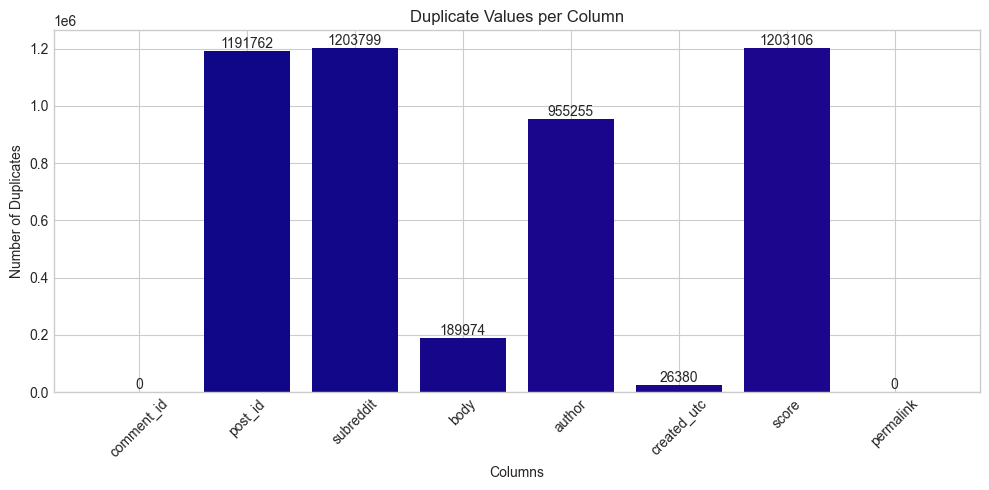

In [16]:
dup_counts = {}
for col in comments.columns:
    dup_counts[col] = comments[col].duplicated().sum()
plt.figure(figsize=(10,5))
bars = plt.bar(dup_counts.keys(), dup_counts.values(), color=plt.cm.plasma(range(len(dup_counts))))
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )
plt.xlabel("Columns")
plt.ylabel("Number of Duplicates")
plt.title("Duplicate Values per Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Duplicate_values_per_column.png')
plt.show()

In [17]:
comments_cat_cols = ['subreddit', 'body', 'author', 'created_utc', 'permalink']
comments_num_cols = ['score']

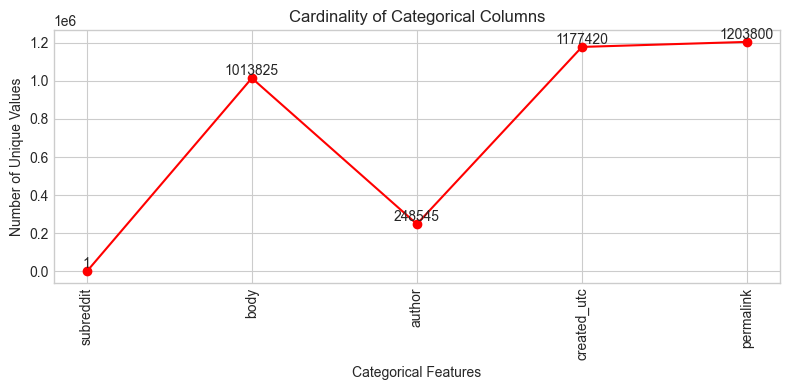

In [18]:
cardinality = comments[comments_cat_cols].nunique()

plt.figure(figsize=(8, 4))
plt.plot(cardinality.index, cardinality.values, marker='o', color='red')

for i, value in enumerate(cardinality.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.title('Cardinality of Categorical Columns')
plt.xlabel('Categorical Features')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('cardinality_of_categorical_columns.png')
plt.show()

In [19]:
print(f'Unique values in subreddit: {comments.subreddit.unique()}')

Unique values in subreddit: ['worldnews']


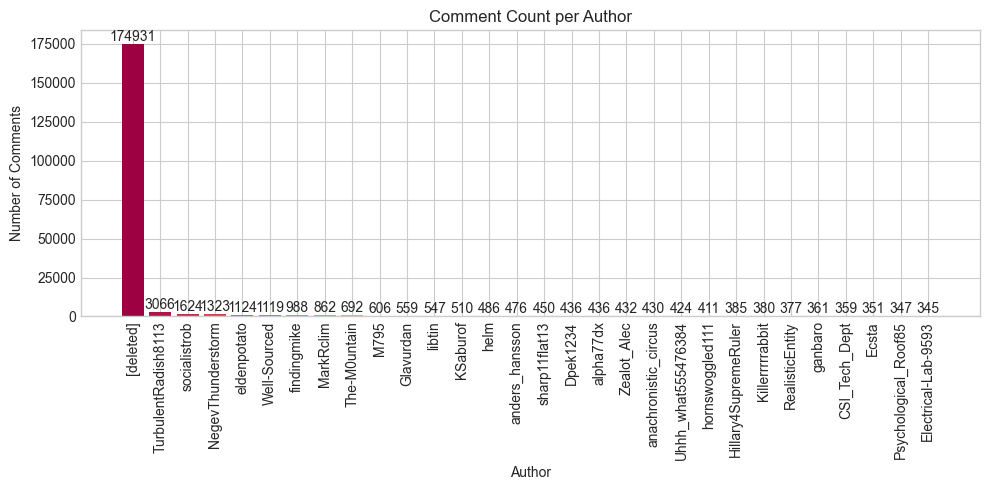

In [20]:
val_counts_authors = comments.author.value_counts().nlargest(30)

colors = plt.cm.Spectral(np.linspace(0, 1, len(val_counts_authors)))

plt.figure(figsize=(10,5))

bars = plt.bar(
    val_counts_authors.index,
    val_counts_authors.values,
    color=colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.xlabel("Author")
plt.ylabel("Number of Comments")
plt.title("Comment Count per Author")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Comment_count_per_author.png')
plt.show()

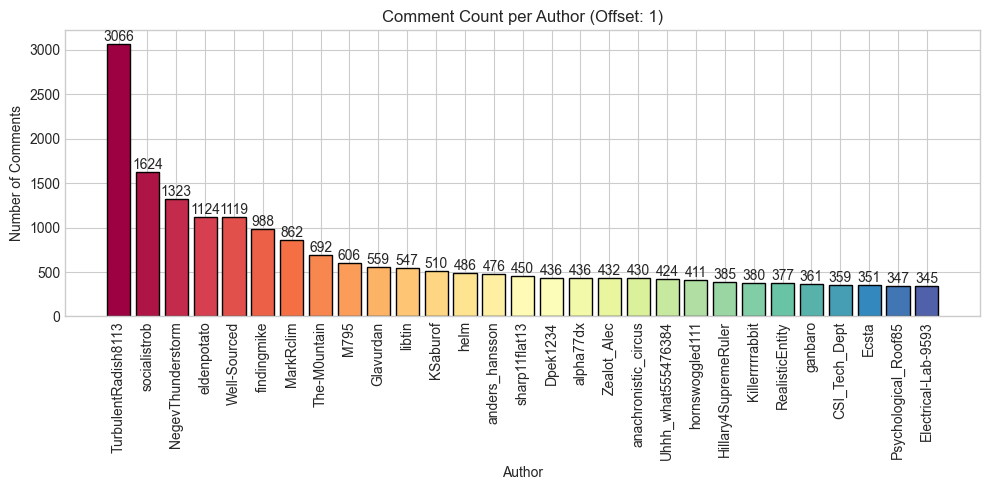

In [21]:
val_counts_authors = comments.author.value_counts().nlargest(30).iloc[1:]

plt.figure(figsize=(10,5))

bars = plt.bar(
    val_counts_authors.index,
    val_counts_authors.values,
    color=colors,
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.xlabel("Author")
plt.ylabel("Number of Comments")
plt.title("Comment Count per Author (Offset: 1)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('comment_count.png')
plt.show()

In [22]:
print(f'Number of unique values in score: {comments.score.nunique()}')

Number of unique values in score: 694


In [23]:
comments.score.describe()

count    1.203800e+06
mean     3.266592e+00
std      1.334346e+01
min     -1.250000e+03
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.314000e+03
Name: score, dtype: float64

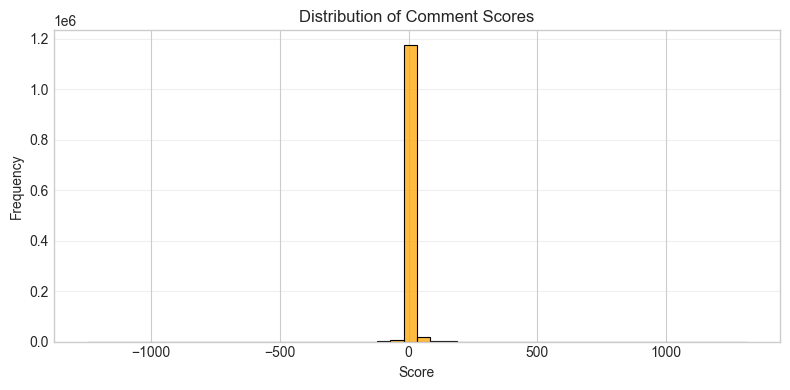

In [24]:
plt.figure(figsize=(8,4))

sns.histplot(comments["score"], bins=50, color="orange")

plt.title("Distribution of Comment Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig('Distribution_of_comment_score.png')
plt.show()

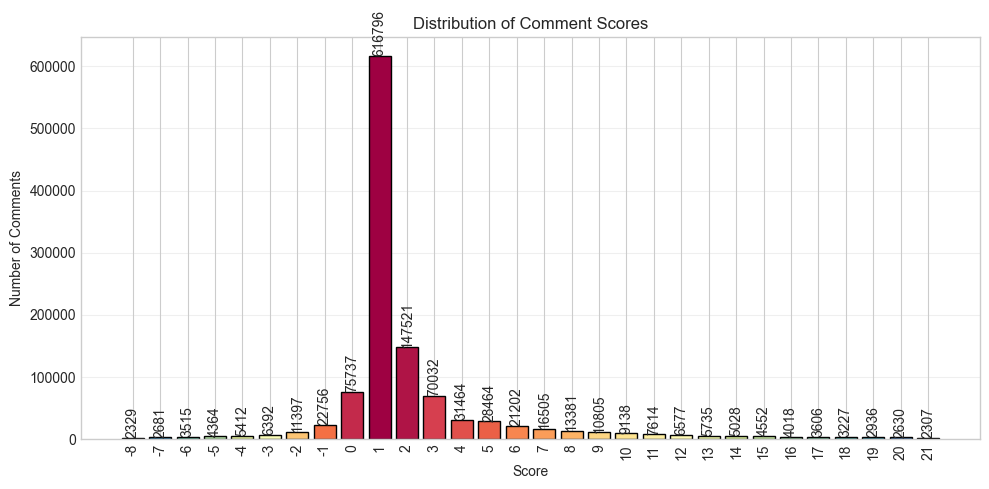

In [25]:
score_counts = comments["score"].value_counts().nlargest(30)

plt.figure(figsize=(10,5))

bars = plt.bar(
    score_counts.index,
    score_counts.values,
    color=colors,
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom",
        rotation=90
    )

plt.title("Distribution of Comment Scores")
plt.xlabel("Score")
plt.ylabel("Number of Comments")

plt.xticks(ticks=score_counts.index, labels=score_counts.index, rotation=90)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('Distribution_of_comment_scores.png')
plt.show()

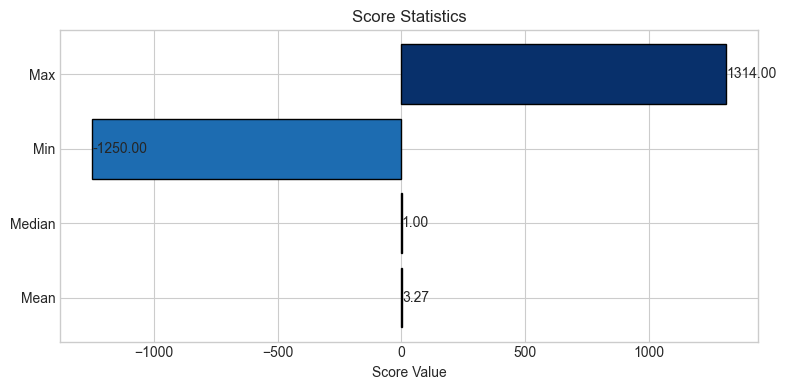

In [26]:
score_stats = {
    "Mean": comments["score"].mean(),
    "Median": comments["score"].median(),
    "Min": comments["score"].min(),
    "Max": comments["score"].max()
}

labels = list(score_stats.keys())
values = list(score_stats.values())

colors = plt.cm.Blues(np.linspace(0.3, 1, len(values)))

plt.figure(figsize=(8,4))
bars = plt.barh(labels, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.xlabel("Score Value")
plt.title("Score Statistics")
plt.tight_layout()
plt.savefig('Score_stats.png')
plt.show()

In [27]:
comments.created_utc = pd.to_datetime(comments.created_utc)

In [28]:
comments = comments.set_index('created_utc')

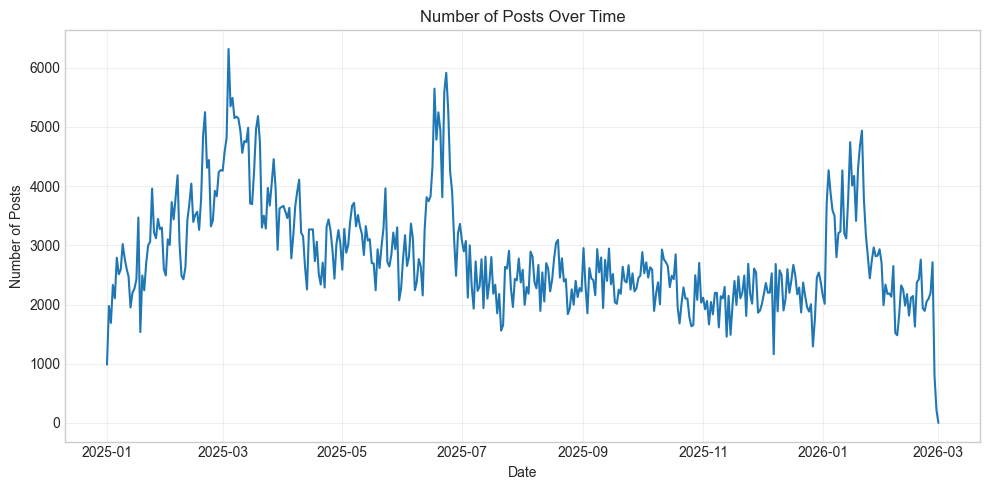

In [29]:
post_trend = comments["post_id"].resample("D").count()

plt.figure(figsize=(10,5))
plt.plot(post_trend.index, post_trend.values)

plt.title("Number of Posts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Posts")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Number_of_posts_over_time.png')
plt.show()

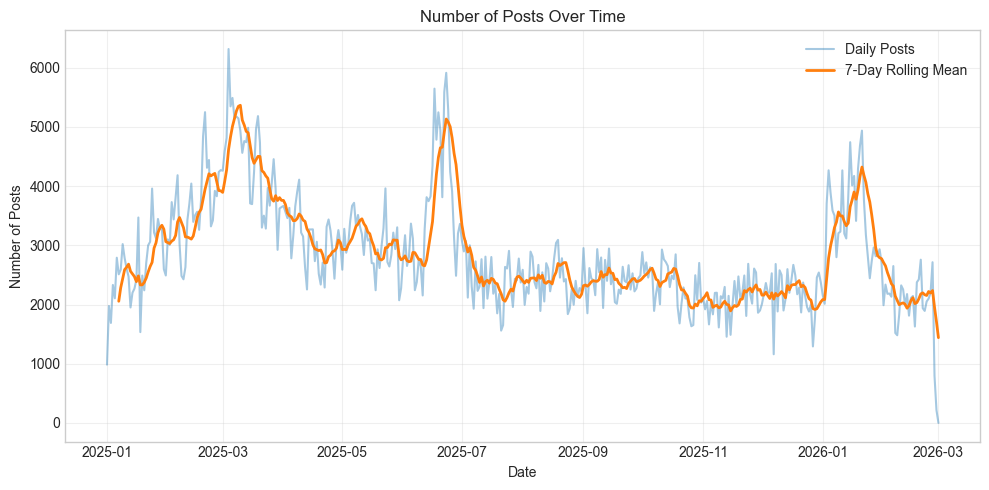

In [30]:
rolling_mean = post_trend.rolling(window=7).mean()

plt.figure(figsize=(10,5))

plt.plot(post_trend.index, post_trend.values, alpha=0.4, label="Daily Posts")

plt.plot(rolling_mean.index, rolling_mean.values, linewidth=2, label="7-Day Rolling Mean")

plt.title("Number of Posts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Posts")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('number_of_posts')
plt.show()

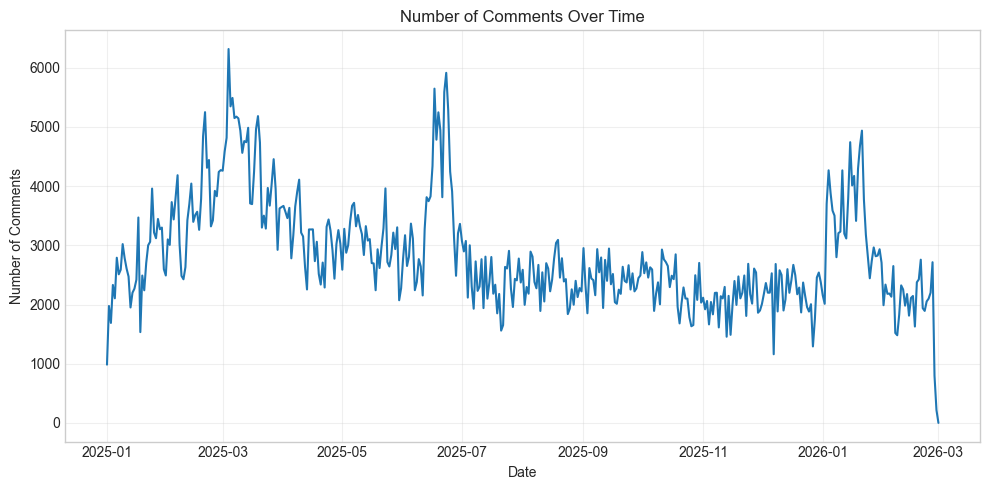

In [31]:
comment_trend = comments["comment_id"].resample("D").count()

plt.figure(figsize=(10,5))
plt.plot(comment_trend.index, comment_trend.values)

plt.title("Number of Comments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Comments")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('number_of_comments_over_time.png')
plt.show()

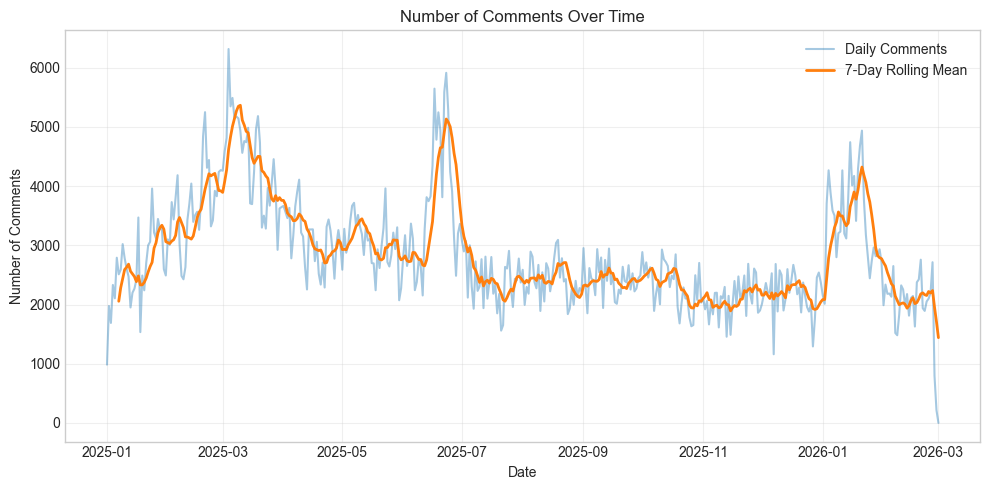

In [32]:
rolling_mean = comment_trend.rolling(window=7).mean()

plt.figure(figsize=(10,5))

plt.plot(comment_trend.index, comment_trend.values, alpha=0.4, label="Daily Comments")

plt.plot(rolling_mean.index, rolling_mean.values, linewidth=2, label="7-Day Rolling Mean")

plt.title("Number of Comments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Comments")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('number_of_comments.png')
plt.show()

In [33]:
def generate_wordcloud(df, column, width=800, height=400,
                       background_color='black', colormap='plasma'):
    text = ' '.join(df[column].astype(str))
    wc = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        colormap=colormap,
        max_words=100
    ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud of {column}')
    plt.savefig('Wordcloud.png')
    plt.show()

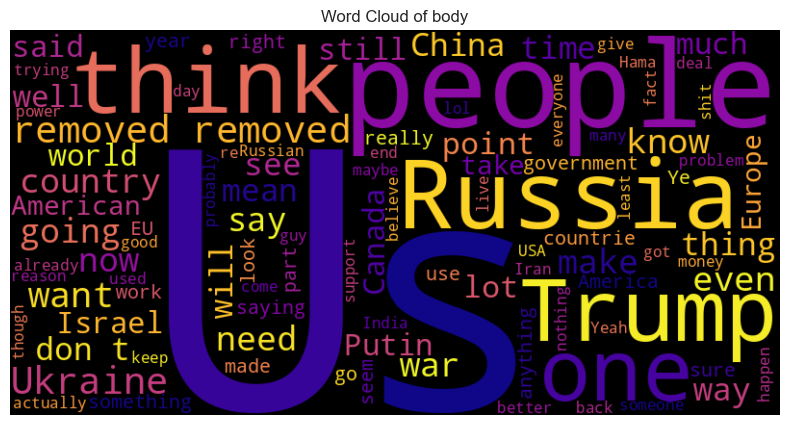

In [34]:
generate_wordcloud(comments, 'body')

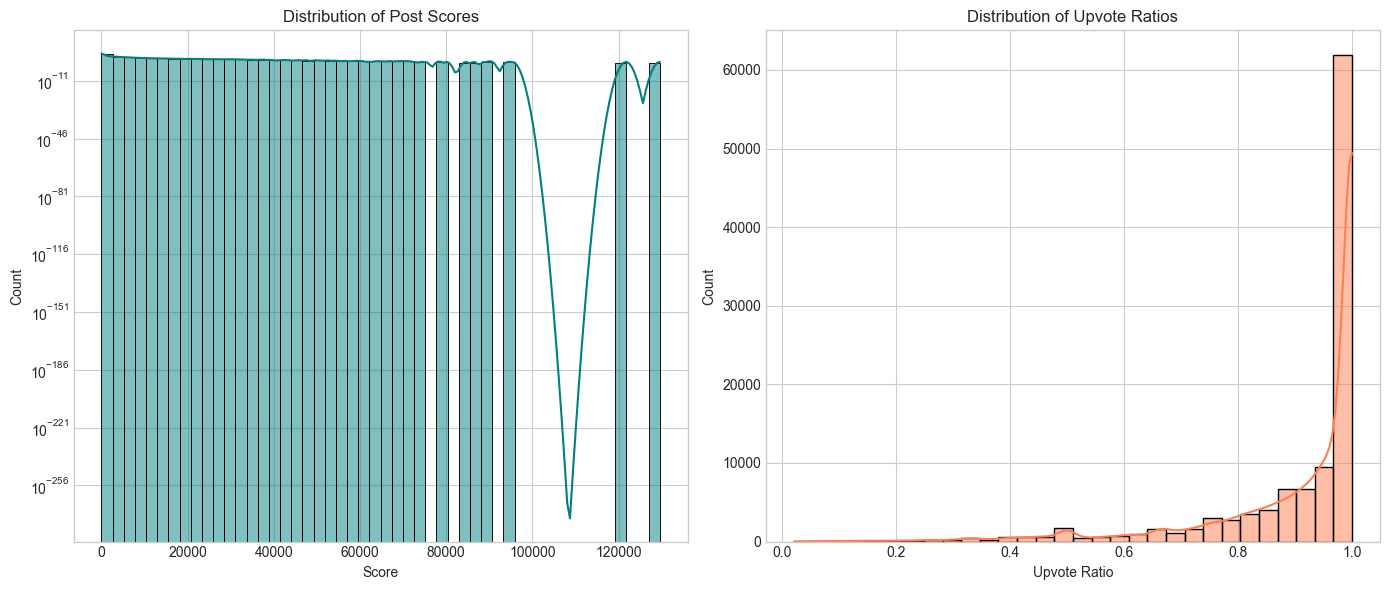

In [35]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(posts['score'], bins=50, kde=True, color='teal')
plt.title('Distribution of Post Scores')
plt.xlabel('Score')
plt.yscale('log')  

plt.subplot(1, 2, 2)
sns.histplot(posts['upvote_ratio'], bins=30, kde=True, color='coral')
plt.title('Distribution of Upvote Ratios')
plt.xlabel('Upvote Ratio')

plt.tight_layout()
plt.savefig('Distribution_of_upvote_ratio.png')
plt.show()

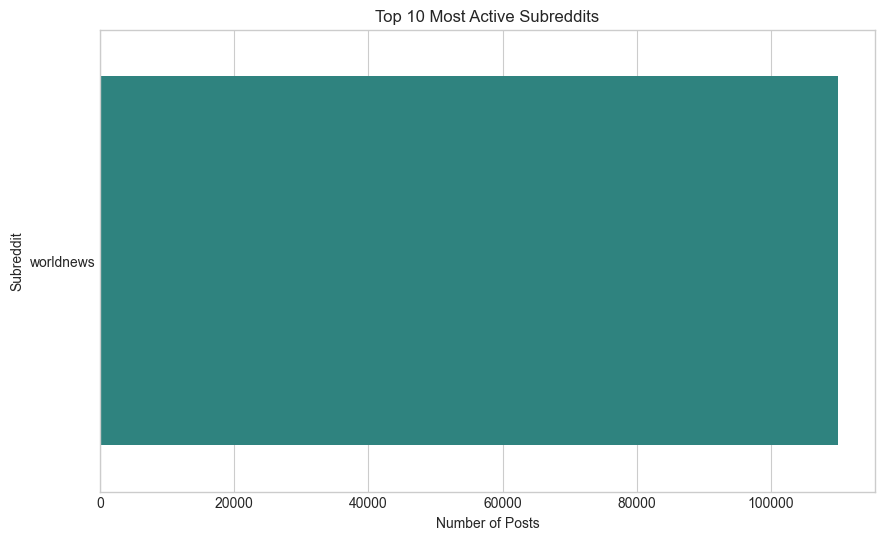

In [36]:
top_subreddits = posts['subreddit'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_subreddits.values, y=top_subreddits.index, palette='viridis')
plt.title('Top 10 Most Active Subreddits')
plt.xlabel('Number of Posts')
plt.ylabel('Subreddit')
plt.savefig('Top_10_Active_subreddits.png')
plt.show()

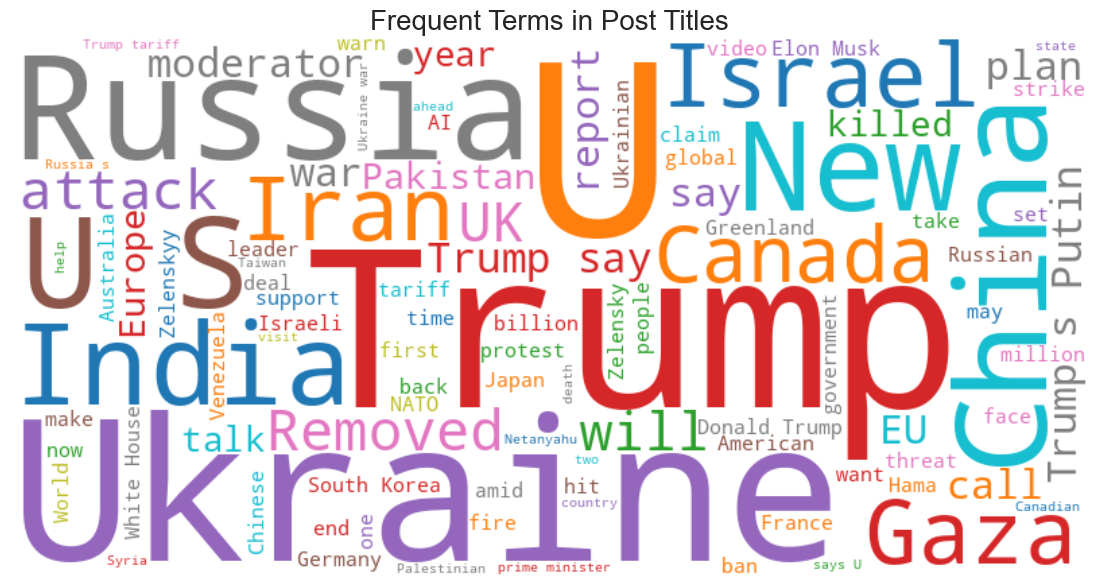

In [37]:
title_text = " ".join(title for title in posts['title'].dropna())

wordcloud_titles = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='tab10',
    max_words=100
).generate(title_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_titles, interpolation='bilinear')
plt.axis('off')
plt.title('Frequent Terms in Post Titles', fontsize=20)
plt.savefig('frequent_terms_in_post_titles.png')
plt.show()

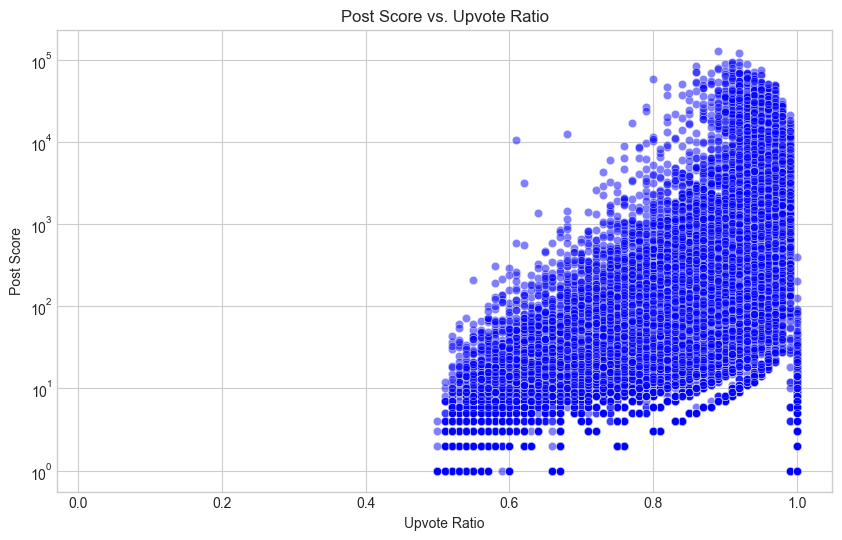

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=posts, x='upvote_ratio', y='score', alpha=0.5, color='blue')
plt.title('Post Score vs. Upvote Ratio')
plt.xlabel('Upvote Ratio')
plt.ylabel('Post Score')
plt.yscale('log')
plt.savefig('upvote_ratio.png') 
plt.show()

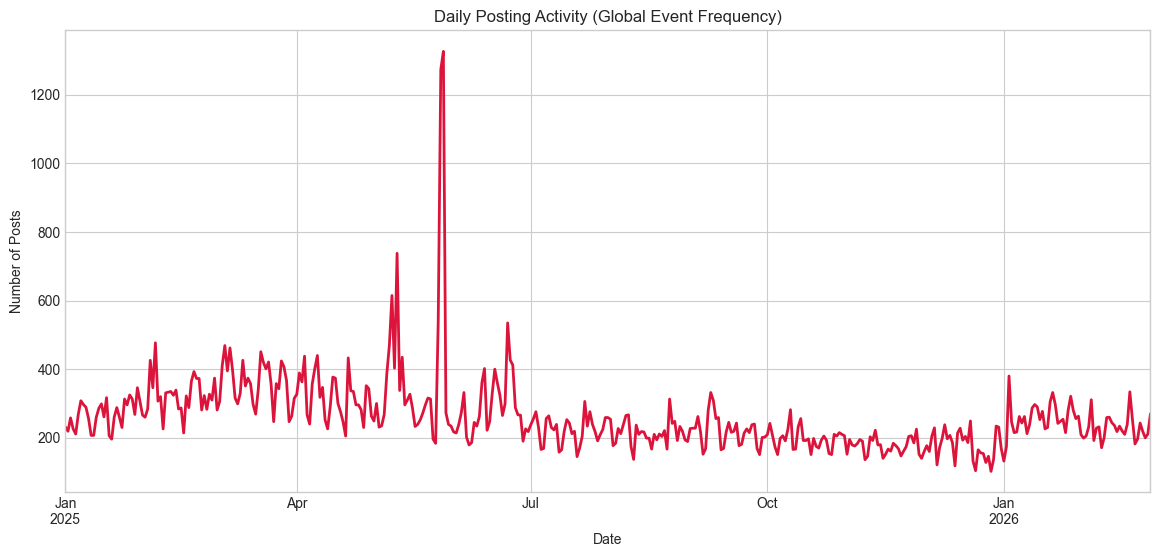

In [43]:
posts['created_at'] = pd.to_datetime(posts['created_utc'])

posts_time = posts.set_index('created_at').resample('D').size()

plt.figure(figsize=(14, 6))
posts_time.plot(color='crimson', linewidth=2)
plt.title('Daily Posting Activity (Global Event Frequency)')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.show()

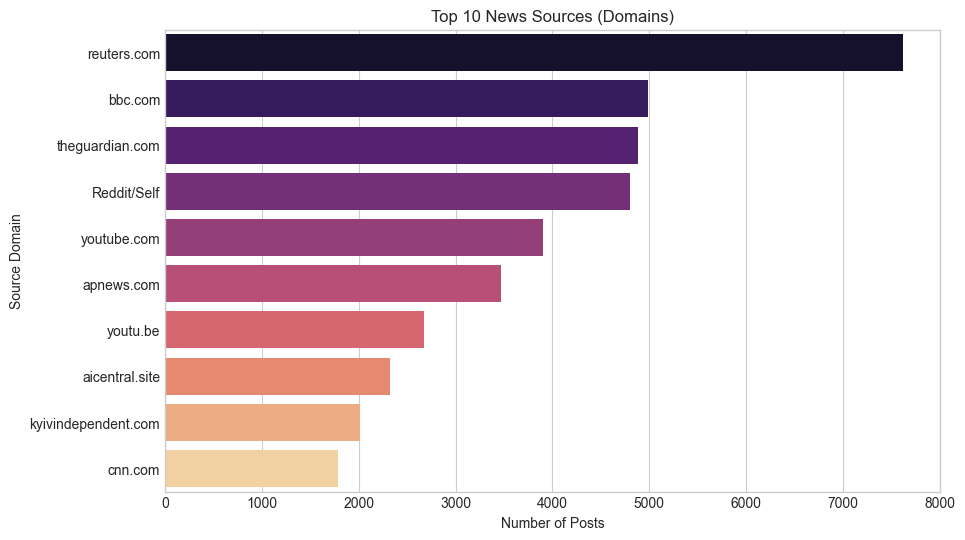

In [42]:
from urllib.parse import urlparse
def extract_domain(url):
    if pd.isna(url): return "Reddit/Self"
    return urlparse(url).netloc.replace('www.', '')

posts['domain'] = posts['url'].apply(extract_domain)
top_domains = posts['domain'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_domains.values, y=top_domains.index, palette='magma')
plt.title('Top 10 News Sources (Domains)')
plt.xlabel('Number of Posts')
plt.ylabel('Source Domain')
plt.show()

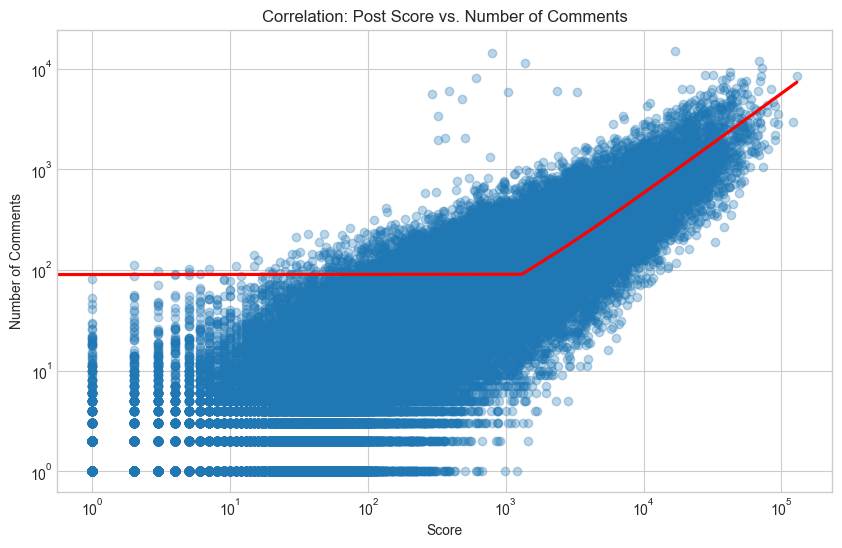

In [44]:
plt.figure(figsize=(10, 6))
sns.regplot(data=posts, x='score', y='num_comments', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation: Post Score vs. Number of Comments')
plt.xlabel('Score')
plt.ylabel('Number of Comments')
plt.xscale('log')
plt.yscale('log')
plt.show()